In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))

from constants import FIGURES_PATH, CAPTIONS_PATH, BANDS_PATH
from pgf_utils import configure_screen, configure_pgf, figure_inches, save_pgf, save_caption, apply_figure_style
from muscle_selection_freq_sweep import (
    NOTEBOOK_GITHUB_URL,
    _trial_job,
    _lqi_trial_job,
    find_bands,
    make_muscle_selection_freq_sweep_figure,
)

In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
SEED        = 0
N_SWEEP     = 128                  # number of sweep frequencies
FREQ_MAX    = 0.5                  # cyc/step  (ω_max = π rad/step)
T_TRIAL     = 1000                 # total steps per trial
T_WARMUP    = 200                  # discard initial transient / burnin
AMPLITUDE   = 0.5                  # sinusoidal amplitude (open-loop)
OFFSET      = 0.5                  # DC offset (open-loop)
MAX_DELTA   = 0.3                  # max |Δangle| per step before treating as IK artifact
SMOOTH_WIN  = 15                   # moving-average window (samples) for display

# Open-loop channel conditions: (label, u0_scale, u1_scale)
CHANNELS = [
    ("$u_0$ only", 1.0, 0.0),
    ("$u_1$ only", 0.0, 1.0),
]

TRIAL_KW = dict(
    offset=OFFSET, amplitude=AMPLITUDE,
    t_trial=T_TRIAL, t_warmup=T_WARMUP, max_delta=MAX_DELTA,
)

# LQI closed-loop conditions: (label, channel_idx)
LQI_CHANNELS = [
    ("$u_0$ LQI", 0),
    ("$u_1$ LQI", 1),
]

LQI_AMPLITUDE   = 1.0    # target population-mean oscillation amplitude
LQI_Q_TRACK     = 2.94
LQI_R_EFFORT    = 40.1
LQI_Q_INT       = 0.032
LQI_LAMBDA_VAR  = 1.0

LQI_TRIAL_KW = dict(
    amplitude_target=LQI_AMPLITUDE,
    t_trial=T_TRIAL, t_warmup=T_WARMUP, max_delta=MAX_DELTA,
    q_track=LQI_Q_TRACK, r_effort=LQI_R_EFFORT,
    q_int=LQI_Q_INT, lambda_var=LQI_LAMBDA_VAR,
)

In [3]:
# ── Sweep ─────────────────────────────────────────────────────────────────────
# Linear spacing from just above DC to Nyquist (0 to π rad/step)
sweep_freqs = np.linspace(FREQ_MAX / N_SWEEP, FREQ_MAX, N_SWEEP)
n_channels  = len(CHANNELS)

jobs = [
    (ci, fi, float(freq), float(u0), float(u1), SEED)
    for ci, (_, u0, u1) in enumerate(CHANNELS)
    for fi, freq in enumerate(sweep_freqs)
]
print(f"{len(jobs)} trials  ({n_channels} channel conditions × {N_SWEEP} freqs × 1 seed)")

256 trials  (2 channel conditions × 128 freqs × 1 seed)


In [4]:
# ── Simulation ────────────────────────────────────────────────────────────────
results = np.zeros((n_channels, N_SWEEP, 2))  # [channel, freq, (sh, el)]

with tqdm(total=len(jobs), desc="frequency sweep") as pbar:
    for ci, fi, dsh, del_ in Parallel(n_jobs=-1, return_as="generator_unordered")(
        delayed(_trial_job)(*job, **TRIAL_KW) for job in jobs
    ):
        results[ci, fi, 0] = dsh
        results[ci, fi, 1] = del_
        pbar.update(1)

print("Done.")

frequency sweep:   0%|          | 0/256 [00:00<?, ?it/s]

Done.


In [5]:
# ── LQI simulation ────────────────────────────────────────────────────────────
lqi_jobs = [
    (ci, fi, float(freq), int(ch_idx), SEED)
    for ci, (_, ch_idx) in enumerate(LQI_CHANNELS)
    for fi, freq in enumerate(sweep_freqs)
]
print(f"{len(lqi_jobs)} LQI trials  ({len(LQI_CHANNELS)} channel conditions × {N_SWEEP} freqs × 1 seed)")

lqi_results = np.zeros((len(LQI_CHANNELS), N_SWEEP, 2))

with tqdm(total=len(lqi_jobs), desc="LQI sweep") as pbar:
    for ci, fi, dsh, del_ in Parallel(n_jobs=-1, return_as="generator_unordered")(
        delayed(_lqi_trial_job)(*job, **LQI_TRIAL_KW) for job in lqi_jobs
    ):
        lqi_results[ci, fi, 0] = dsh
        lqi_results[ci, fi, 1] = del_
        pbar.update(1)

print("Done.")

256 LQI trials  (2 channel conditions × 128 freqs × 1 seed)


LQI sweep:   0%|          | 0/256 [00:00<?, ?it/s]

Done.


Identified bands:
  S$+$    ω* = 0.417 rad/step  (f* = 0.0664 cyc/step)
  S$-$    ω* = 0.761 rad/step  (f* = 0.1211 cyc/step)
  E$+$    ω* = 1.203 rad/step  (f* = 0.1914 cyc/step)
  E$-$    ω* = 2.013 rad/step  (f* = 0.3203 cyc/step)


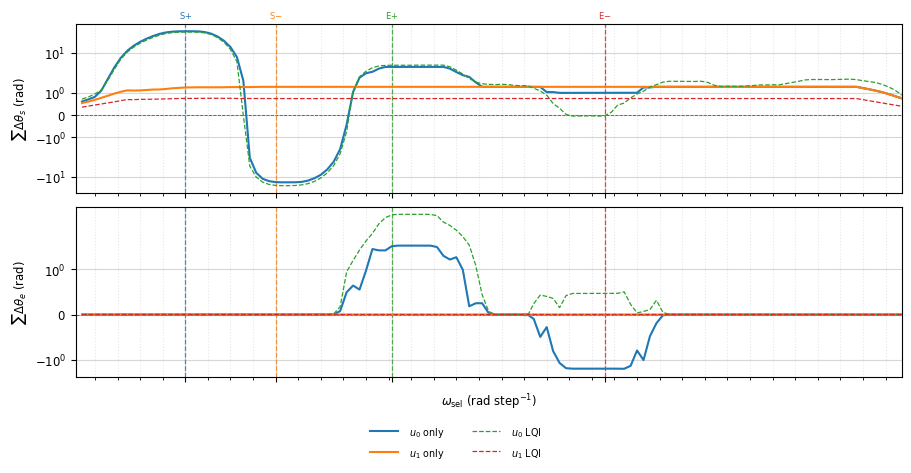

In [6]:
# ── Band identification and display ───────────────────────────────────────────
ch0 = 0  # u0 open-loop for band identification
bands = find_bands(sweep_freqs, results[ch0, :, 0], results[ch0, :, 1])

print("Identified bands:")
for freq, label, colour in bands:
    print(f"  {label:6s}  ω* = {2*np.pi*freq:.3f} rad/step  (f* = {freq:.4f} cyc/step)")

all_results = np.concatenate([results, lqi_results], axis=0)
all_labels  = [lbl for lbl, *_ in CHANNELS] + [lbl for lbl, _ in LQI_CHANNELS]
all_styles  = ["-"] * len(CHANNELS) + ["--"] * len(LQI_CHANNELS)

configure_screen()
fig = make_muscle_selection_freq_sweep_figure(
    sweep_freqs, all_results,
    channel_labels=all_labels,
    bands=bands,
    figsize=(9, 5),
    smooth_window=SMOOTH_WIN,
    linestyles=all_styles,
)
apply_figure_style(fig)
plt.show()

In [7]:
# ── Save bands ────────────────────────────────────────────────────────────────
import numpy as np
BANDS_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    BANDS_PATH,
    freqs=np.array([f for f, _, _ in bands]),
    labels=np.array([lbl for _, lbl, _ in bands]),
    colours=np.array([c for _, _, c in bands]),
)
print(f"Bands saved to {BANDS_PATH}")

Bands saved to /Users/tahmidazam/Developer/gg4/data/bands.npz


In [8]:
# ── PGF export ────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5
FIG_HEIGHT_FRAC = 0.25
configure_pgf()
fig = make_muscle_selection_freq_sweep_figure(
    sweep_freqs, all_results,
    channel_labels=all_labels,
    bands=bands,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
    smooth_window=SMOOTH_WIN,
    linestyles=all_styles,
)
apply_figure_style(fig)
save_pgf(fig, FIGURES_PATH / "muscle_selection_freq_sweep.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/muscle_selection_freq_sweep.pgf


In [9]:
# ── Caption ───────────────────────────────────────────────────────────────────
band_str = ", ".join(
    f"{lbl.replace('$', '')} at $\\omega^* = {2 * np.pi * freq:.3f}$ rad\\,step\\textsuperscript{{--1}}"
    for freq, lbl, _ in bands
)

caption = (
    r"Muscle-selection frequency sweep. "
    r"At each of "
    f"{N_SWEEP}"
    r" linearly spaced angular frequencies $\omega_\mathrm{sel} \in (0, \pi]$ rad\,step\textsuperscript{--1}, "
    r"four conditions are evaluated: open-loop sinusoidal drive (amplitude $A="
    f"{AMPLITUDE}"
    r"$, centred at "
    f"{OFFSET}"
    r") applied to $u_0$ or $u_1$ independently (solid lines), and LQI closed-loop "
    r"control targeting a population-mean oscillation of amplitude "
    f"{LQI_AMPLITUDE}"
    r" through $u_0$ or $u_1$ alone (dashed lines). "
    r"The arm is observed via hand position and inverse kinematics. "
    r"Top: signed cumulative shoulder displacement $\sum\Delta\theta_s$; "
    r"bottom: cumulative elbow displacement $\sum\Delta\theta_e$, "
    r"each summed over the post-warmup window of "
    f"{T_TRIAL - T_WARMUP}"
    r" steps (symlog $y$-axis, linear threshold $\pm 1$ rad); "
    r"curves smoothed with a "
    f"{SMOOTH_WIN}"
    r"-sample moving average. "
    r"Coloured vertical lines mark the four empirically identified band frequencies "
    r"(" + band_str + r"), "
    r"identified from the open-loop $u_0$ response by peak displacement magnitude "
    r"(S$\pm$) and peak elbow selectivity $|\Delta\theta_e|/(|\Delta\theta_e|+|\Delta\theta_s|)$ (E$\pm$)."
)

save_caption(CAPTIONS_PATH / "muscle_selection_freq_sweep.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/muscle_selection_freq_sweep.tex
Muscle-selection frequency sweep. At each of 128 linearly spaced angular frequencies $\omega_\mathrm{sel} \in (0, \pi]$ rad\,step\textsuperscript{--1}, four conditions are evaluated: open-loop sinusoidal drive (amplitude $A=0.5$, centred at 0.5) applied to $u_0$ or $u_1$ independently (solid lines), and LQI closed-loop control targeting a population-mean oscillation of amplitude 1.0 through $u_0$ or $u_1$ alone (dashed lines). The arm is observed via hand position and inverse kinematics. Top: signed cumulative shoulder displacement $\sum\Delta\theta_s$; bottom: cumulative elbow displacement $\sum\Delta\theta_e$, each summed over the post-warmup window of 800 steps (symlog $y$-axis, linear threshold $\pm 1$ rad); curves smoothed with a 15-sample moving average. Coloured vertical lines mark the four empirically identified band frequencies (S+ at $\omega^* = 0.417$ rad\,step\textsuperscript{--1}, S- 